CSV 합쳐보기
↓
눈 데이터 찾아보기
↓
첫눈 날짜 뽑아보기
↓
기온 그래프 그려보기
↓
feature 이것저것 만들어보기
↓
모델 A 돌려보기
↓
모델 B 돌려보기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# 1996년부터 2025년까지의 서울 기상 관측 데이터를 불러옵니다.
file1 = pd.read_csv("../data/OBS_ASOS_DD_20260923125529.csv", encoding="cp949")
file2 = pd.read_csv("../data/OBS_ASOS_DD_20260923125852.csv", encoding="cp949")
file3 = pd.read_csv("../data/OBS_ASOS_DD_20260923130020.csv", encoding="cp949")

df = pd.concat([file1, file2, file3], ignore_index=True)

df.shape

(10958, 62)

In [4]:
df["일시"]= pd.to_datetime(df["일시"])
df=df.sort_values(by="일시").reset_index(drop=True)

df[["일시", "평균기온(°C)", "최저기온(°C)", "최고기온(°C)", "일강수량(mm)", "기사"]].head()

,일시,평균기온(°C),최저기온(°C),최고기온(°C),일강수량(mm),기사
0,1996-01-01,-3.2,-7.9,2.5,NaN,NaN
1,1996-01-02,0.2,-3.9,3.9,0.0,{비}2345-{비}{강도0}2400-
2,1996-01-03,-4.5,-8.5,5.5,0.0,-{비}-0030.
3,1996-01-04,-5.4,-10.7,-0.1,NaN,NaN
4,1996-01-05,-0.1,-2.1,2.0,2.0,{진눈깨비}1145-{진눈깨비}{강도0}1200-{비}1240-{비}{강도0}150...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10958 entries, 0 to 10957
Data columns (total 62 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   지점                   10958 non-null  int64         
 1   지점명                  10958 non-null  str           
 2   일시                   10958 non-null  datetime64[us]
 3   평균기온(°C)             10958 non-null  float64       
 4   최저기온(°C)             10957 non-null  float64       
 5   최저기온 시각(hhmi)        10957 non-null  float64       
 6   최고기온(°C)             10957 non-null  float64       
 7   최고기온 시각(hhmi)        10957 non-null  float64       
 8   강수 계속시간(hr)          4268 non-null   float64       
 9   10분 최다 강수량(mm)       2758 non-null   float64       
 10  10분 최다강수량 시각(hhmi)   1994 non-null   float64       
 11  1시간 최다강수량(mm)        2758 non-null   float64       
 12  1시간 최다 강수량 시각(hhmi)  2015 non-null   float64       
 13  일강수량(mm)             4268 non-null   float

첫눈 날짜가 30년동안 어떻게 분포하는지

In [6]:
# 눈이 관측된 날짜만 추출
snow_days = df[
    df["기사"].fillna("").str.contains(r"\{눈\}", regex=True)
].copy()

# 9월 이후 데이터만 사용
snow_days = snow_days[snow_days["일시"].dt.month >= 9]

# 연도 컬럼 생성
snow_days["연도"] = snow_days["일시"].dt.year

# 연도별 첫 번째 눈 날짜 추출
first_snow = (
    snow_days
    .sort_values("일시")
    .groupby("연도")
    .first()
    .reset_index()
)

first_snow[["연도", "일시"]]

,연도,일시
0,1996,1996-11-17
1,1997,1997-10-30
2,1998,1998-11-19
3,1999,1999-11-27
4,2000,2000-12-12
5,2001,2001-11-27
6,2002,2002-11-13
7,2003,2003-12-08
8,2004,2004-11-26
9,2005,2005-11-29


In [7]:
first_snow["첫눈_일수"] = first_snow["일시"].dt.dayofyear

first_snow[["연도", "일시", "첫눈_일수"]]

,연도,일시,첫눈_일수
0,1996,1996-11-17,322
1,1997,1997-10-30,303
2,1998,1998-11-19,323
3,1999,1999-11-27,331
4,2000,2000-12-12,347
5,2001,2001-11-27,331
6,2002,2002-11-13,317
7,2003,2003-12-08,342
8,2004,2004-11-26,331
9,2005,2005-11-29,333


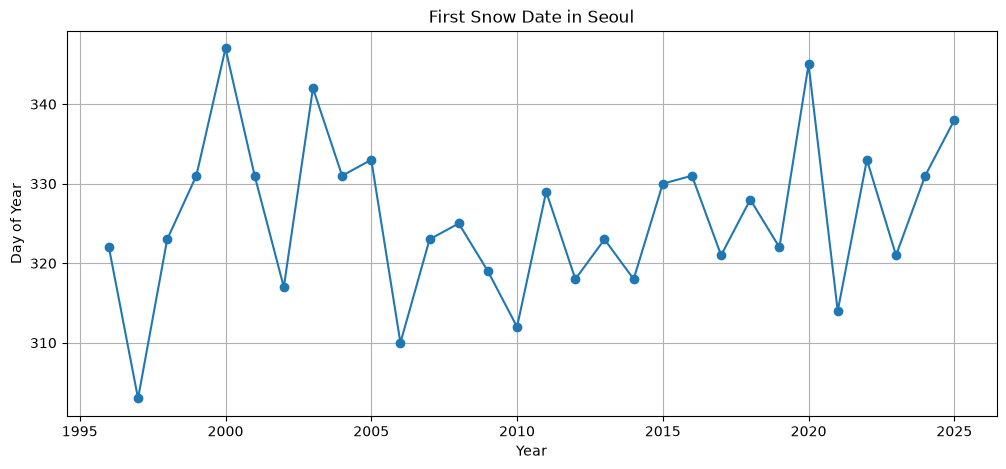

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    first_snow["연도"],
    first_snow["첫눈_일수"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Day of Year")
plt.title("First Snow Date in Seoul")
plt.grid()

plt.show()

In [9]:
mean_day = first_snow["첫눈_일수"].mean()
std_day = first_snow["첫눈_일수"].std()

print("평균 첫눈 일수:", mean_day)
print("표준편차:", std_day)

평균 첫눈 일수: 325.7
표준편차: 10.076089827254249


지난 30년동안 첫눈은 평균적으로 1년 중 326일째 왔고, 연도에 따라 대략 +-10일 정도 차이가 있었다.
y  = 첫눈 일수 
x = ?? 

In [11]:
mean_date = pd.Timestamp("2025-01-01") + pd.Timedelta(days=round(mean_day) - 1)

print("평균 첫눈 날짜:", mean_date.strftime("%m월 %d일"))

earliest = first_snow.loc[first_snow["첫눈_일수"].idxmin()]
latest = first_snow.loc[first_snow["첫눈_일수"].idxmax()]

print("가장 빠른 첫눈:", earliest["일시"])
print("가장 늦은 첫눈:", latest["일시"])

평균 첫눈 날짜: 11월 22일
가장 빠른 첫눈: 1997-10-30 00:00:00
가장 늦은 첫눈: 2000-12-12 00:00:00


In [ ]:
first_snow["첫눈_일수"].describe()
#count  → 데이터 개수
#mean   → 평균
#std    → 표준편차
#min    → 가장 빠른 첫눈
#25%    → 하위 25%
#50%    → 중앙값
#75%    → 상위 25%
#max    → 가장 늦은 첫눈

count     30.00000
mean     325.70000
std       10.07609
min      303.00000
25%      319.50000
50%      324.00000
75%      331.00000
max      347.00000
Name: 첫눈_일수, dtype: float64

### 초기 Feature 설계

첫눈 날짜를 예측하기 위한 초기 Feature로 **첫눈이 오기 전 가을철의 기상 특성**을 사용한다.

원본 데이터는 일별 기상 관측 데이터이지만, 예측 대상인 첫눈 날짜는 연도별로 하나의 값이 존재한다. 따라서 각 연도의 일별 데이터를 그대로 사용하는 대신, **9~10월의 기상 데이터를 연도별로 집계하여 하나의 학습 데이터로 변환**한다.

초기 Feature는 다음과 같이 구성하였다.

| Feature | 계산 방법               | 의미                 |
| ------- | ------------------- | ------------------ |
| 평균기온    | 9~10월 일평균기온의 평균     | 가을철 전반적인 기온 수준     |
| 평균최저기온  | 9~10월 일별 최저기온의 평균   | 가을철 아침·야간의 기온 수준   |
| 평균최고기온  | 9~10월 일별 최고기온의 평균   | 가을철 낮 시간대의 기온 수준   |
| 총강수량    | 9~10월 일강수량의 합계      | 가을철 전체 강수량         |
| 평균습도    | 9~10월 일평균 상대습도의 평균  | 가을철 대기의 평균적인 습윤 상태 |
| 평균이슬점   | 9~10월 일평균 이슬점온도의 평균 | 공기 중 수증기량 및 습윤 정도  |

예를 들어 평균기온은 다음과 같이 계산한다.

**평균기온 = 9~10월 일평균기온의 합 ÷ 해당 기간의 관측일수**

강수량의 경우 기간 전체에 어느 정도의 강수가 있었는지를 나타내기 위해 평균이 아닌 **합계**를 사용한다.

**총강수량 = 9~10월 일강수량의 합**

이렇게 생성된 6개의 기상 변수를 모델의 입력값 **X(Feature)**로 사용하고, 각 연도의 실제 첫눈 날짜를 1월 1일부터 경과한 일수로 변환한 **`첫눈_일수`를 y(Target)**로 사용한다.

즉, 초기 모델은 다음과 같은 관계를 학습하도록 설계한다.

**해당 연도의 가을철 기상 특성(X) → 해당 연도의 첫눈 발생 시점(y)**

다만 현재 9~10월 데이터를 사용하는 것은 **첫눈 발생 시점과 관련성이 있을 것으로 예상되는 기상 특성을 탐색하기 위한 초기 Feature 설계**이며, 해당 변수들이 실제로 첫눈 날짜를 결정한다고 가정하는 것은 아니다. 이후 모델 평가와 Feature 중요도 등을 통해 실제 예측에 유효한 변수를 검증하고 추가적인 Feature Engineering을 진행한다.

또한 현재 데이터에서 가장 빠른 첫눈은 **10월 30일**에 관측되었기 때문에, 10월 31일까지의 데이터를 사용할 경우 일부 연도에서는 첫눈 발생 이후의 정보가 Feature에 포함되는 **데이터 누수(Data Leakage)** 가능성이 있다.

따라서 초기 모델에서는 전체적인 학습 파이프라인을 구축하기 위해 9~10월 데이터를 우선 사용하고, 이후 모델 개선 단계에서는 예측 기준일(Cut-off Date)을 **10월 15일 등 첫눈 발생 이전 시점으로 조정**하여 데이터 누수를 제거하고 기간별 모델 성능을 비교할 예정이다.


In [ ]:
# ============================================================
# Feature Engineering
# 첫눈 날짜를 예측하기 위해 첫눈이 오기 전 가을철 기상정보를
# 연도별 Feature(X)로 생성한다.
#
# 예측 기준:
# - 입력(X): 해당 연도의 9~10월 기상정보
# - 정답(y): 해당 연도의 첫눈 날짜(day of year)
#
# 일별 데이터를 그대로 사용하는 것이 아니라,
# 각 연도의 9~10월 데이터를 대표할 수 있도록 평균/합계로 집계한다.
# ============================================================


# 1. 9월~10월 데이터 추출
# 첫눈이 주로 10월 말~12월 사이에 관측되므로
# 첫눈 이전의 가을 기상 상태를 Feature로 사용한다.
fall = df[
    df["일시"].dt.month.isin([9, 10])
].copy()


# 2. 연도별 집계를 위해 연도 컬럼 생성
# 예: 1996-09-01 → 연도 = 1996
fall["연도"] = fall["일시"].dt.year


# 3. 연도별 9~10월 기상 데이터를 하나의 행으로 요약
features = fall.groupby("연도").agg(

    # 9~10월 일평균기온의 평균
    # (9~10월 평균기온의 합) / 관측일수
    평균기온=("평균기온(°C)", "mean"),

    # 9~10월 일별 최저기온의 평균
    # 가을철 전반적인 아침/야간 기온 수준을 표현
    평균최저기온=("최저기온(°C)", "mean"),

    # 9~10월 일별 최고기온의 평균
    # 가을철 전반적인 낮 기온 수준을 표현
    평균최고기온=("최고기온(°C)", "mean"),

    # 9~10월에 기록된 일강수량의 합
    # 해당 기간의 전체 강수량을 표현
    총강수량=("일강수량(mm)", "sum"),

    # 9~10월 일평균 상대습도의 평균
    # 가을철 대기의 평균적인 습윤 상태를 표현
    평균습도=("평균 상대습도(%)", "mean"),

    # 9~10월 일평균 이슬점온도의 평균
    # 공기 중 수증기량 및 습윤 정도를 나타내는 변수
    평균이슬점=("평균 이슬점온도(°C)", "mean")

).reset_index()


# 4. Feature(X)와 실제 첫눈 날짜(y) 결합
#
# features
# 연도 | 평균기온 | 평균최저기온 | ... | 평균이슬점
#
# first_snow
# 연도 | 첫눈_일수
#
# 두 데이터를 '연도'를 기준으로 합친다.
model_df = features.merge(
    first_snow[["연도", "첫눈_일수"]],
    on="연도"
)


# 5. 결과 확인
model_df.head()

,연도,평균기온,평균최저기온,평균최고기온,총강수량,평균습도,평균이슬점,첫눈_일수
0,1996,18.168852,13.711475,23.296721,101.3,64.522951,10.563934,322
1,1997,16.742623,11.895082,22.181967,122.4,58.939344,7.906557,303
2,1998,19.963934,15.775410,24.814754,205.3,68.470492,13.600000,323
3,1999,18.501639,14.626230,23.006557,458.9,73.054098,13.140984,331
4,2000,17.726230,13.836066,21.957377,196.6,67.447541,11.195082,347
